In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib as plt
import numpy as np
from tensorflow.keras import layers, Model

2026-01-19 16:01:23.347897: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768838483.541906      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768838483.603079      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768838484.092793      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768838484.092832      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768838484.092834      25 computation_placer.cc:177] computation placer alr

# Part 1: Data Preparation
## 1. Dataset Loading
### Split into training and testing subsets

In [2]:
(ds_train,_),ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:90%]','train[90%:]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
    )

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

I0000 00:00:1768838508.788710      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768838508.792680      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 396 extraneous bytes before marker 0xd9
Corrupt JPEG data: 228 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 252 ext

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.1OBLFT_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


## 2. Preprocessing:
### o Resize all images to 64×64 pixels
### o Normalize pixel values to the [-1, 1] range
### o Cast labels to integer format
### o Create training batches with labels

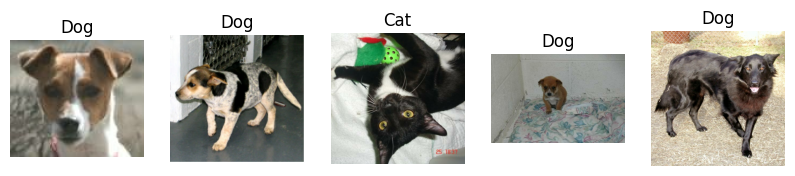

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for i, (image, label) in enumerate(ds_train.take(5)): # Display 5 images
    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title('Dog' if label == 1 else 'Cat')
    plt.axis('off')
plt.show()

In [4]:
# Define target dimension
TARGET_HEIGHT = 64
TARGET_WIDTH = 64

def preprocess_image(image, label):
    # Resize all images to 64x64 pixels
    image = tf.image.resize(image, (TARGET_HEIGHT, TARGET_WIDTH))
    # Normalize pixel values to the [-1, 1] range
    image = tf.keras.layers.Rescaling(scale=1./127.5, offset=-1)(image)
    # Cast labels to integer format (tfds.load with as_supervised usually does this, but good to be explicit)
    label = tf.cast(label, tf.int32)
    return image, label

In [5]:
BATCH_SIZE = 32

ds_train_processed = ds_train.map(preprocess_image)
ds_train_batched = ds_train_processed.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

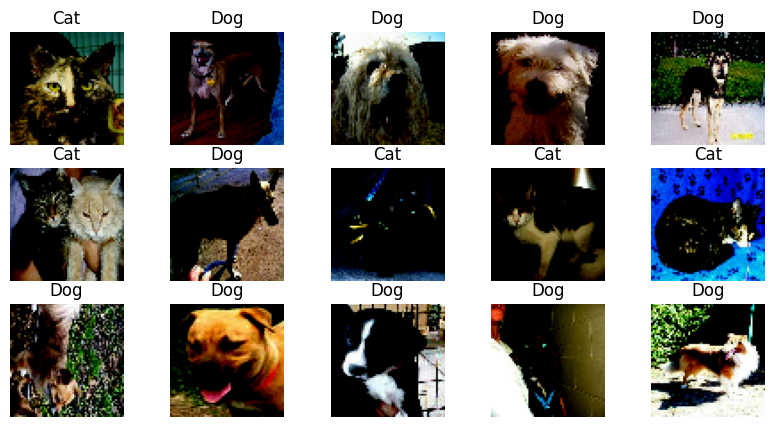

In [6]:
plt.figure(figsize=(10, 5))
for i, (image, label) in enumerate(ds_train_batched.take(15)): # Display 15 images
    plt.subplot(3, 5, i + 1)
    plt.imshow((image[0])) # Denormalize from [-1, 1] to [0, 1] for display
    # plt.imshow((image[0] + 1) / 2) # Denormalize from [-1, 1] to [0, 1] for display
    plt.title('Dog' if label[0] == 1 else 'Cat') # Use the label of the first image
    plt.axis('off')
plt.show()

# Part 2: Conditional GAN Architecture
## 1. Generator
### o Accepts both noise vector and class label as input
### o Uses label embedding and concatenates it with noise
### o Builds up to a 64×64×3 image using Conv2DTranspose layers

In [7]:
NUM_CLASSES = 2
def build_cgan_generator(latent_dim=100, num_classes=NUM_CLASSES):
    # 1. Label Input & Embedding
    label_input = layers.Input(shape=(1,), name="label_input")
    # Embedding maps label to a vector, then flatten to match noise shape
    label_embedding = layers.Embedding(num_classes, latent_dim)(label_input)
    label_embedding = layers.Flatten()(label_embedding)

    # 2. Noise Input
    noise_input = layers.Input(shape=(latent_dim,), name="noise_input")

    # 3. Concatenate Label + Noise
    merged = layers.Concatenate()([noise_input, label_embedding])

    # 4. Foundation for 4x4 image
    x = layers.Dense(4 * 4 * 512)(merged)
    x = layers.Reshape((4, 4, 512))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 5. Upsampling to 64x64x3
    # 4x4 -> 8x8
    x = layers.Conv2DTranspose(256, kernel_size=4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 8x8 -> 16x16
    x = layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 16x16 -> 32x32
    x = layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 32x32 -> 64x64
    x = layers.Conv2DTranspose(3, kernel_size=4, strides=2, padding="same", activation="tanh")(x)

    return Model([noise_input, label_input], x, name="cGAN_Generator")

generator = build_cgan_generator()
generator.summary()


Model: "cGAN_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 100)    │        200 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 100)       │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 200)       │          0 │ noise_input[0][0… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8192)      │  1,646,592 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 4, 4, 512) │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 4, 4, 512) │      2,048 │ reshape[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 4, 4, 512) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 256) │  2,097,408 │ re_lu[0][0]       │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 16, 16,    │    524,416 │ re_lu_1[0][0]     │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 32, 32,    │    131,136 │ re_lu_2[0][0]     │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,406,667 (16.81 MB)

 Trainable params: 4,404,747 (16.80 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 2. Discriminator
### o Accepts both real/fake image and class label
### o Embeds label and concatenates it with image
### o Uses Conv2D layers to classify input as real/fake

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_cgan_discriminator(img_shape=(64, 64, 3), num_classes=NUM_CLASSES):
    # 1. Label Input & Embedding
    label_input = layers.Input(shape=(1,), name="label_input")

    # Embed label and expand to match image spatial dimensions (64x64)
    # We create a 1D vector, then use Dense to expand it to 64*64*1
    le = layers.Embedding(num_classes, 50)(label_input)
    le = layers.Dense(img_shape[0] * img_shape[1])(le)
    le = layers.Reshape((img_shape[0], img_shape[1], 1))(le)

    # 2. Image Input
    img_input = layers.Input(shape=img_shape, name="image_input")

    # 3. Concatenate Image + Label (adds the label as a 4th channel)
    merged = layers.Concatenate()([img_input, le])

    # 4. Downsampling with Conv2D layers
    # 64x64 -> 32x32
    x = layers.Conv2D(64, kernel_size=4, strides=2, padding="same")(merged)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # 32x32 -> 16x16
    x = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # 16x16 -> 8x8
    x = layers.Conv2D(256, kernel_size=4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # 5. Output Layer
    x = layers.Flatten()(x)
    x = layers.Dropout(0.4)(x)
    output = layers.Dense(1, activation="sigmoid")(x) # Real vs Fake

    return Model([img_input, label_input], output, name="cGAN_Discriminator")

discriminator = build_cgan_discriminator()
discriminator.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "cGAN_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │        100 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 4096)   │    208,896 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 64, 64, 1) │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 64, 4) │          0 │ image_input[0][0… │
│ (Concatenate)       │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      4,160 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 32, 32,    │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │    131,200 │ leaky_re_lu[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 256) │    524,544 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16384)     │          0 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16384)     │          0 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │     16,385 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 886,821 (3.38 MB)

 Trainable params: 886,053 (3.38 MB)

 Non-trainable params: 768 (3.00 KB)

## Part 3: Loss Functions and Optimizer
### • Generator Loss: Binary cross-entropy encouraging discriminator to classify generated images as real
### • Discriminator Loss: Binary cross-entropy distinguishing real vs fake images
### • Optimizers: Adam optimizer for both networks


In [9]:
# Standard Adam optimizer settings for GANs
GAN_BETA1 = 0.5
LEARNING_RATE = 0.0002

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=GAN_BETA1)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=GAN_BETA1)

# Use 'from_logits=False' if the discriminator output uses a sigmoid activation
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(real_output, fake_output):
    #Loss on real images (should be all 1s)
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)

    #Loss on fake image(should be all 0s)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)

    #Total loss is the sum
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    #Loss on fake images (should be all 1s)
    return cross_entropy(tf.ones_like(fake_output), fake_output)

## Part 4: Training the Model
### • Train the generator and discriminator alternately
### • Use @tf.function for optimized performance
### • Train for a minimum of 10 epochs
### • Print training progress per epoch


In [10]:
import tensorflow as tf

@tf.function
def train_step(images, labels, generator, discriminator, gen_optimizer, disc_optimizer, latent_dim):
    # Generate random noise for the batch
    batch_size = tf.shape(images)[0]
    noise = tf.random.normal([batch_size, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # 1. Generate fake images using noise and the real labels
        generated_images = generator([noise, labels], training=True)

        # 2. Get discriminator output for real images + labels
        real_output = discriminator([images, labels], training=True)
        # 3. Get discriminator output for fake images + labels
        fake_output = discriminator([generated_images, labels], training=True)

        # 4. Calculate Losses
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # 5. Calculate and apply gradients for Discriminator
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    disc_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    # 6. Calculate and apply gradients for Generator
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gen_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))

    return gen_loss, disc_loss


In [11]:
import time

def train(dataset, epochs, generator, discriminator, generator_optimizer, discriminator_optimizer,latent_dim):
    for epoch in range(epochs):
        start = time.time()

        # Accumulators for avg loss reporting
        gen_loss_avg = tf.keras.metrics.Mean()
        disc_loss_avg = tf.keras.metrics.Mean()

        for images_batch, label_batch in dataset:
            gen_loss, disc_loss = train_step(images_batch,
                                             label_batch,
                                             generator,
                                             discriminator,
                                             generator_optimizer,
                                             discriminator_optimizer,
                                             latent_dim=100)
            gen_loss_avg(gen_loss)
            disc_loss_avg(disc_loss)

        # Print progress per epoch
        print(f"Epoch {epoch + 1}, "
              f"Gen Loss: {gen_loss_avg.result()}, "
              f"Disc Loss: {disc_loss_avg.result()}, "
              f"Time: {time.time() - start}")

        print("---------------------------------------------------")
        print("---------------------------------------------------")
        print("---------------------------------------------------")

        print(f"Epoch {epoch+1}/{epochs} | "
          f"Gen Loss: {gen_loss_avg.result():.4f} | "
          f"Disc Loss: {disc_loss_avg.result():.4f} | "
          f"Time: {time.time()-start:.2f}s")

#Execute Training
LATENT_DIM = 100
EPOCHS = 10
# train(ds_train_batched, EPOCHS, generator, discriminator, generator_optimizer, discriminator_optimizer)

# dataset = Your preprocessed tf.data.Dataset yielding (64,64,3) images and labels
train(ds_train_batched, EPOCHS, generator, discriminator, generator_optimizer, discriminator_optimizer, LATENT_DIM)


I0000 00:00:1768838578.032512      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


Epoch 1, Gen Loss: 2.1034860610961914, Disc Loss: 0.8915605545043945, Time: 33.78508996963501
---------------------------------------------------
---------------------------------------------------
---------------------------------------------------
Epoch 1/10 | Gen Loss: 2.1035 | Disc Loss: 0.8916 | Time: 33.79s
Epoch 2, Gen Loss: 2.039682626724243, Disc Loss: 0.8370651006698608, Time: 21.964549779891968
---------------------------------------------------
---------------------------------------------------
---------------------------------------------------
Epoch 2/10 | Gen Loss: 2.0397 | Disc Loss: 0.8371 | Time: 21.97s
Epoch 3, Gen Loss: 2.3358678817749023, Disc Loss: 0.7911660075187683, Time: 22.501512050628662
---------------------------------------------------
---------------------------------------------------
---------------------------------------------------
Epoch 3/10 | Gen Loss: 2.3359 | Disc Loss: 0.7912 | Time: 22.50s
Epoch 4, Gen Loss: 2.3922815322875977, Disc Loss: 0.73

## Part 5: Evaluation and Visualization
### • Generate images conditioned on randomly chosen labels
### • Display generated images with corresponding label titles
### • Ensure images are normalized back to [0, 1] for display


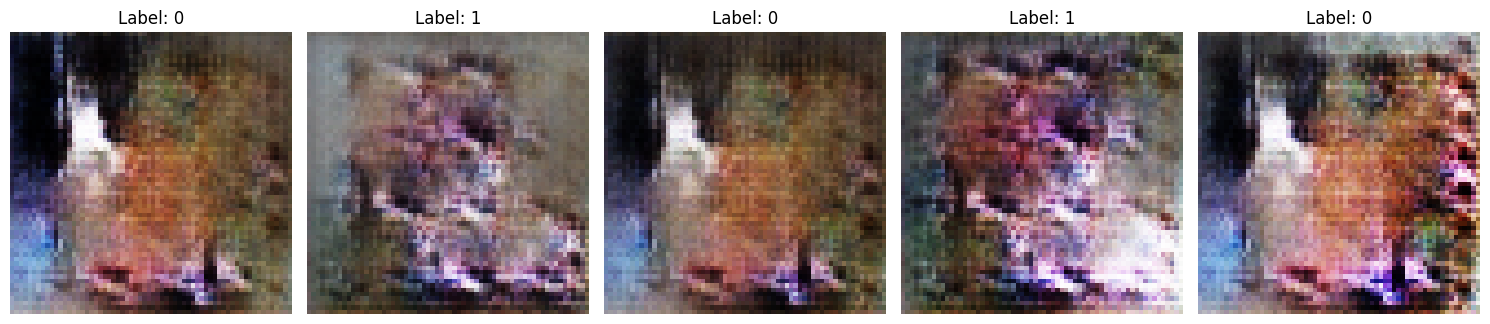

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_generated_images(generator, num_classes, latent_dim=100, num_examples=5):
    # 1. Prepare random noise and random labels
    noise = tf.random.normal([num_examples, latent_dim])
    # Pick random class labels
    random_labels = tf.random.uniform([num_examples], minval=0, maxval=num_classes, dtype=tf.int32)

    # 2. Generate images (inference mode: training=False)
    generated_images = generator([noise, random_labels], training=False)

    # 3. Normalize back to [0, 1] for visualization
    # Formula: (img + 1) / 2
    normalized_images = (generated_images + 1.0) / 2.0

    # 4. Display the images
    plt.figure(figsize=(15, 5))
    for i in range(num_examples):
        plt.subplot(1, num_examples, i + 1)
        # Convert to numpy and ensure the range is clipped to [0, 1] just in case
        img_to_show = np.clip(normalized_images[i], 0, 1)

        plt.imshow(img_to_show)
        plt.title(f"Label: {random_labels[i].numpy()}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage after training:
visualize_generated_images(generator, num_classes=NUM_CLASSES )
